# Hồi quy Logistic NHỊ PHÂN — minh họa hướng đối tượng

Bám note **[[logistic-regression]]** (slide L4 — TS. Cao Tiến Dũng).

**Các hàm tường minh** trong lớp `LogisticRegressionGD`:

| Hàm | Ý nghĩa |
|---|---|
| `sigmoid(z)` | σ(z) = 1/(1+e⁻ᶻ) — ép z về xác suất (0,1) |
| `net_input(X)` | z = X·w + b (tổ hợp tuyến tính) |
| `predict_proba(X)` | σ(z) = xác suất thuộc lớp 1 |
| `predict(X)` | cắt ngưỡng 0.5 → nhãn 0/1 |
| `log_loss(X, y)` | Binary Cross-Entropy (hàm chi phí) |
| `gradient(X, y)` | **đạo hàm**: ∂L/∂w = (1/m)Σ(σ−y)·x , ∂L/∂b = (1/m)Σ(σ−y) |
| `fit(X, y)` | Gradient Descent, **DỪNG khi max\|đạo hàm\| < 1e-5** |
<!-- sinh code minh họa hồi qui logictic nhị phân. xây dựng theo kiểu đối tượng , viết tường minh các hàm, đạo hàm, dự đoán, điều kiện dừng là trị tuyệt đối đạo hàm nhỏ hơn 0.00001, vẽ minh họa đường thẳng theo n lần huấn luyện
 -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False

## 1) Mô hình — hướng đối tượng

In [2]:
class LogisticRegressionGD:
    """Hồi quy Logistic nhị phân huấn luyện bằng Gradient Descent (batch)."""

    def __init__(self, lr=0.1, max_epochs=200_000, tol=1e-5):
        self.lr = lr                  # tốc độ học α
        self.max_epochs = max_epochs  # trần số vòng lặp (an toàn)
        self.tol = tol                # ĐIỀU KIỆN DỪNG: max|đạo hàm| < tol
        self.w = None                 # trọng số (vector p chiều)
        self.b = None                 # bias (số vô hướng)
        self.history = []             # (epoch, w, b, loss, grad_max) để vẽ

    # ---- các hàm toán tường minh -------------------------------------
    @staticmethod
    def sigmoid(z):
        """σ(z) = 1/(1+e^−z), viết ổn định số học để không tràn exp."""
        return np.where(z >= 0,
                        1.0 / (1.0 + np.exp(-z)),
                        np.exp(z) / (1.0 + np.exp(z)))

    def net_input(self, X):
        """z = w·x + b  (giống hồi quy tuyến tính)."""
        return X @ self.w + self.b

    def predict_proba(self, X):
        """Xác suất thuộc lớp 1 = σ(z)."""
        return self.sigmoid(self.net_input(X))

    def predict(self, X, threshold=0.5):
        """Cắt ngưỡng → nhãn rời rạc 0/1."""
        return (self.predict_proba(X) >= threshold).astype(int)

    def log_loss(self, X, y):
        """Binary Cross-Entropy: L = −mean[ y·log(p) + (1−y)·log(1−p) ]."""
        p = self.predict_proba(X)
        eps = 1e-12                       # tránh log(0)
        return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    def gradient(self, X, y):
        """Đạo hàm tường minh của Log Loss qua sigmoid (rút gọn đẹp):
              ∂L/∂w = (1/m) Σ (σ(z) − y)·x
              ∂L/∂b = (1/m) Σ (σ(z) − y)
        """
        m = X.shape[0]
        error = self.predict_proba(X) - y     # σ(z) − y = sai số
        grad_w = (X.T @ error) / m
        grad_b = np.mean(error)
        return grad_w, grad_b

    # ---- huấn luyện --------------------------------------------------
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])   # khởi tạo w = 0
        self.b = 0.0                    # khởi tạo b = 0
        self.history.clear()

        for epoch in range(self.max_epochs):
            grad_w, grad_b = self.gradient(X, y)

            # cập nhật:  tham_so := tham_so − α · đạo_hàm
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            loss = self.log_loss(X, y)
            grad_max = max(np.max(np.abs(grad_w)), abs(grad_b))
            self.history.append((epoch, self.w.copy(), self.b, loss, grad_max))

            # ĐIỀU KIỆN DỪNG: trị tuyệt đối đạo hàm nhỏ hơn 1e-5
            if grad_max < self.tol:
                print(f"✅ Dừng ở epoch {epoch}: max|đạo hàm| = {grad_max:.2e} "
                      f"< tol = {self.tol}  | loss = {loss:.6f}")
                break
        else:
            print(f"⚠️ Chạm trần {self.max_epochs} epoch (max|đạo hàm| = {grad_max:.2e}).")
        return self

## 2) Dữ liệu minh họa — 2 đặc trưng để vẽ được đường ranh giới

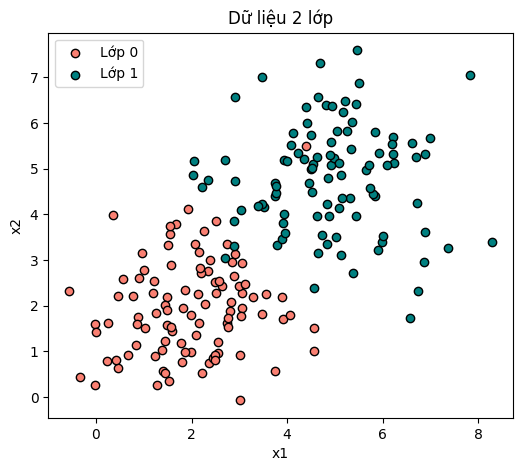

In [3]:
def make_data(n=200, seed=42):
    """Hai cụm Gaussian chồng nhẹ (không tách hoàn toàn → đạo hàm hội tụ thật)."""
    rng = np.random.default_rng(seed)
    n0 = n // 2
    X0 = rng.normal(loc=[2.0, 2.0], scale=1.2, size=(n0, 2))       # lớp 0
    X1 = rng.normal(loc=[4.8, 4.8], scale=1.2, size=(n - n0, 2))   # lớp 1
    X = np.vstack([X0, X1])
    y = np.array([0] * n0 + [1] * (n - n0), dtype=float)
    return X, y

X, y = make_data()

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="salmon", edgecolor="k", label="Lớp 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="teal",   edgecolor="k", label="Lớp 1")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.title("Dữ liệu 2 lớp")
plt.show()

## 3) Huấn luyện (dừng khi `max|đạo hàm| < 1e-5`)

In [4]:
model = LogisticRegressionGD(lr=0.1, max_epochs=200_000, tol=1e-5)
model.fit(X, y)

print(f"\nTrọng số học được:  w = {model.w}  |  b = {model.b:.4f}")
acc = (model.predict(X) == y).mean()
print(f"Độ chính xác trên tập huấn luyện: {acc:.2%}")

print("\nVí dụ dự đoán xác suất P(lớp 1):")
for xi in [[2, 2], [4.8, 4.8], [3.4, 3.4]]:
    p = model.predict_proba(np.array([xi]))[0]
    print(f"  x = {xi}  →  P(lớp 1) = {p:.3f}  →  lớp {int(p >= 0.5)}")

✅ Dừng ở epoch 113432: max|đạo hàm| = 1.00e-05 < tol = 1e-05  | loss = 0.092534

Trọng số học được:  w = [2.26290506 2.64248725]  |  b = -16.1227
Độ chính xác trên tập huấn luyện: 98.50%

Ví dụ dự đoán xác suất P(lớp 1):
  x = [2, 2]  →  P(lớp 1) = 0.002  →  lớp 0
  x = [4.8, 4.8]  →  P(lớp 1) = 0.999  →  lớp 1
  x = [3.4, 3.4]  →  P(lớp 1) = 0.635  →  lớp 1


## 4) Vẽ đường ranh giới tiến hóa qua n lần huấn luyện

Ranh giới:  `w₁x₁ + w₂x₂ + b = 0`  →  `x₂ = −(w₁·x₁ + b) / w₂`

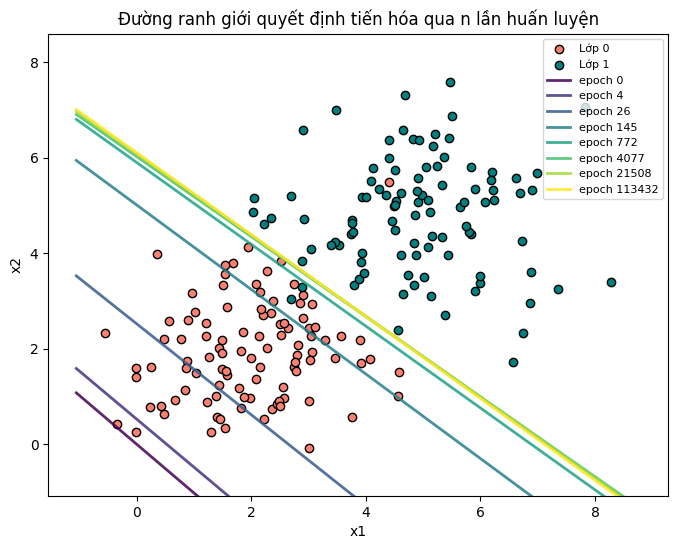

In [5]:
def plot_boundary_evolution(model, X, y, n_lines=8):
    last = len(model.history) - 1
    idxs = np.unique(np.geomspace(1, last + 1, n_lines).astype(int) - 1)  # giãn log

    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c="salmon", edgecolor="k", label="Lớp 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c="teal",   edgecolor="k", label="Lớp 1")

    x1 = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    cmap = plt.cm.viridis
    for i, idx in enumerate(idxs):
        epoch, w, b, loss, _ = model.history[idx]
        if abs(w[1]) < 1e-9:
            continue
        x2 = -(w[0] * x1 + b) / w[1]
        plt.plot(x1, x2, color=cmap(i / max(len(idxs) - 1, 1)),
                 lw=2, alpha=0.85, label=f"epoch {epoch}")

    plt.xlabel("x1"); plt.ylabel("x2")
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.title("Đường ranh giới quyết định tiến hóa qua n lần huấn luyện")
    plt.legend(fontsize=8, loc="upper right")
    plt.show()

plot_boundary_evolution(model, X, y)

## 5) Hàm chi phí giảm dần (lồi → 1 đáy)

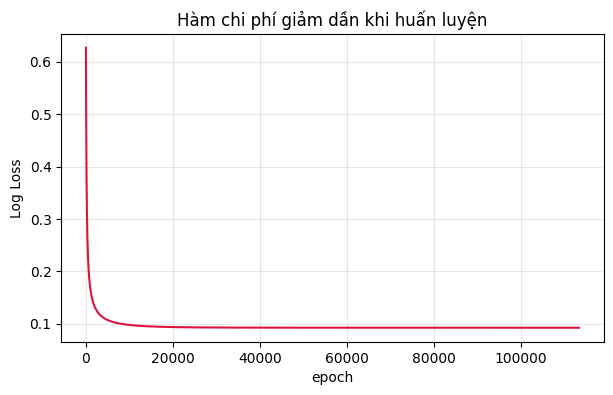

In [6]:
epochs = [h[0] for h in model.history]
losses = [h[3] for h in model.history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, losses, color="crimson")
plt.xlabel("epoch"); plt.ylabel("Log Loss")
plt.title("Hàm chi phí giảm dần khi huấn luyện")
plt.grid(alpha=0.3)
plt.show()

---
# 📊 ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI

> Mọi độ đo phân loại đều **suy ra từ 4 con số** của Confusion Matrix. Nắm 4 số này là nắm tất cả.

## 7) Ma trận nhầm lẫn (Confusion Matrix)

Đối chiếu **nhãn dự đoán** với **nhãn thật**, ra 4 ô:

| | Đoán **Dương** | Đoán **Âm** |
|---|---|---|
| **Thật Dương** | ✅ **TP** (bắt đúng) | ❌ **FN** — *bỏ sót* (Lỗi loại II) |
| **Thật Âm** | ❌ **FP** — *báo nhầm* (Lỗi loại I) | ✅ **TN** (cho qua đúng) |

**Ví dụ lọc thư rác** (Dương = "rác"):
- **TP**: thư rác → bị chặn đúng 👍
- **TN**: thư thường → vào hộp thư đúng 👍
- **FP**: thư **quan trọng** bị tống vào spam 😱 (báo động giả — *Lỗi loại I*)
- **FN**: thư rác **lọt** vào hộp thư 😒 (bỏ sót — *Lỗi loại II*)

> 🔑 Hai loại lỗi FP và FN **không bằng nhau về hậu quả** — và đó chính là lý do ta cần Precision/Recall chứ không chỉ Accuracy.

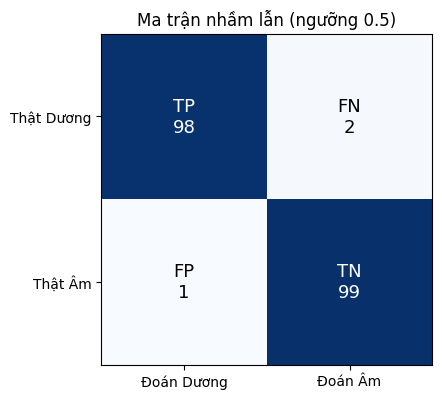

TP=98  FN=2  FP=1  TN=99   (tổng = 200)


In [7]:
def confusion_matrix_manual(y_true, y_pred):
    """Đếm 4 ô TP, FP, FN, TN — tường minh."""
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    return TP, FP, FN, TN

y_pred = model.predict(X)                       # ngưỡng mặc định 0.5
TP, FP, FN, TN = confusion_matrix_manual(y, y_pred)

cm = np.array([[TP, FN], [FP, TN]])
txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"], [f"FP\n{FP}", f"TN\n{TN}"]])
fig, ax = plt.subplots(figsize=(5, 4.3))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, txt[i, j], ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["Đoán Dương", "Đoán Âm"])
ax.set_yticks([0, 1], ["Thật Dương", "Thật Âm"])
ax.set_title("Ma trận nhầm lẫn (ngưỡng 0.5)")
plt.show()
print(f"TP={TP}  FN={FN}  FP={FP}  TN={TN}   (tổng = {TP+FN+FP+TN})")

## 8) Accuracy, Precision & Recall

Cả 3 đều tính từ 4 ô trên:

| Độ đo | Công thức | Trả lời câu hỏi | Trực giác |
|---|---|---|---|
| **Accuracy** | (TP+TN) / tổng | "Đoán đúng bao nhiêu %?" | Tốt **khi lớp cân bằng**; **đánh lừa** khi lệch |
| **Precision** | TP / (TP+FP) | "Trong số đã **gắn cờ Dương**, bao nhiêu **đúng**?" | Cao = **ít báo nhầm** (ít FP) |
| **Recall** | TP / (TP+FN) | "Trong số **Dương thật**, **bắt được** bao nhiêu?" | Cao = **ít bỏ sót** (ít FN) |

**Cách nhớ bằng ví dụ "câu cá":**
- **Precision** = trong mẻ cá kéo lên, bao nhiêu là cá thật (không phải rác)? → sợ kéo nhầm rác.
- **Recall** = trong tất cả cá dưới hồ, bắt được bao nhiêu? → sợ để sót cá.

> ⚖️ **Precision và Recall thường ĐÁNH ĐỔI nhau:** siết ngưỡng (chỉ gắn cờ khi rất chắc) → Precision ↑ nhưng Recall ↓ (bỏ sót nhiều hơn). Nới ngưỡng → ngược lại. Không có bữa trưa miễn phí.

In [8]:
def metrics_from_cm(TP, FP, FN, TN):
    """Tính các độ đo từ 4 ô (chia an toàn khi mẫu = 0)."""
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return accuracy, precision, recall, f1

accuracy, precision, recall, f1 = metrics_from_cm(TP, FP, FN, TN)
print(f"Accuracy  = (TP+TN)/tổng = {accuracy:.3f}")
print(f"Precision = TP/(TP+FP)   = {precision:.3f}   → trong số ĐOÁN dương, {precision:.0%} là đúng")
print(f"Recall    = TP/(TP+FN)   = {recall:.3f}   → trong số dương THẬT, bắt được {recall:.0%}")

Accuracy  = (TP+TN)/tổng = 0.985
Precision = TP/(TP+FP)   = 0.990   → trong số ĐOÁN dương, 99% là đúng
Recall    = TP/(TP+FN)   = 0.980   → trong số dương THẬT, bắt được 98%


## 9) F1-Score

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

- Là **trung bình ĐIỀU HÒA** (harmonic mean) của Precision và Recall.
- **Dùng khi** muốn mô hình tốt **CẢ hai** — không được hi sinh cái nào.
- **Vì sao điều hòa chứ không phải trung bình cộng?** Trung bình điều hòa **phạt nặng khi 2 số lệch nhau**. Nếu Precision=0.95 nhưng Recall=0.10 thì:
  - Trung bình cộng = 0.525 (nghe ổn → **đánh lừa!**)
  - F1 = 0.18 (phản ánh đúng: mô hình **tệ** vì bỏ sót gần hết)
- 👉 F1 cao **chỉ khi cả Precision lẫn Recall đều cao**.

In [9]:
print(f"F1 của mô hình = {f1:.3f}\n")

# Minh họa: vì sao TRUNG BÌNH ĐIỀU HÒA phạt nặng khi P, R lệch nhau
print("Khi Precision & Recall lệch nhau, F1 bị kéo về phía SỐ NHỎ:")
print(f"{'Precision':>10} {'Recall':>8} {'TB cộng':>9} {'F1':>7}")
for P, R in [(0.95, 0.95), (0.95, 0.50), (0.95, 0.10), (0.50, 0.50)]:
    tb_cong = (P + R) / 2
    f1_demo = 2 * P * R / (P + R)
    print(f"{P:>10.2f} {R:>8.2f} {tb_cong:>9.2f} {f1_demo:>7.2f}")

F1 của mô hình = 0.985

Khi Precision & Recall lệch nhau, F1 bị kéo về phía SỐ NHỎ:
 Precision   Recall   TB cộng      F1
      0.95     0.95      0.95    0.95
      0.95     0.50      0.72    0.66
      0.95     0.10      0.53    0.18
      0.50     0.50      0.50    0.50


## 10) 🧭 Khi nào dùng độ đo nào?

Câu hỏi vàng: **"Sai lầm nào tốn kém hơn — báo nhầm (FP) hay bỏ sót (FN)?"**

| Ưu tiên | Khi nào | Vì sao | Ví dụ |
|---|---|---|---|
| **Precision** | Sợ **báo động giả** (FP đắt) | Gắn cờ nhầm gây hậu quả/phiền | **Lọc thư rác** — đừng tống nhầm email quan trọng vào spam |
| **Recall** | Sợ **bỏ sót** (FN nguy hiểm) | Để lọt 1 ca là thảm họa | **Tầm soát ung thư** — thà báo nhầm còn hơn bỏ sót bệnh nhân |
| **F1** | Cần **cân bằng** cả hai / chưa rõ cái nào nặng | Tổng hợp P & R thành 1 số | **Phát hiện gian lận** — vừa bắt đúng, vừa không làm phiền khách thật |
| **Accuracy** | Lớp **CÂN BẰNG** | Đơn giản, dễ hiểu | Phân loại ảnh mèo/chó 50–50 |
| **AUC-ROC** | **So sánh mô hình**, độc lập ngưỡng | Không phụ thuộc 1 ngưỡng cụ thể | Chọn model nào tốt hơn tổng thể |
| **PR-AUC** | Lớp **lệch nặng** (dương hiếm) | ROC lạc quan quá mức khi lệch | Gian lận 0.1%, click quảng cáo |

**Quy trình thực hành khi chưa chắc:**
```
1. Lớp có cân bằng không?  → KHÔNG → bỏ Accuracy ngay.
2. Nhìn F1 trước (tổng hợp nhanh).
3. Chưa đủ rõ? → tách Precision & Recall RIÊNG, xem model lệch về đâu.
4. Nghiêng theo bài toán:  sợ FN → Recall  ·  sợ FP → Precision.
```
> ⚠️ **Cái bẫy kinh điển:** dữ liệu 99% âm, model "luôn đoán âm" → **Accuracy 99%** nhưng **Recall = 0%** (bỏ sót sạch lớp hiếm). Ta sẽ tái hiện cái bẫy này ở Mục 13.

## 11) Đường cong ROC & AUC — và cách **so sánh mô hình**

**ROC** = quét **mọi ngưỡng**, vẽ **TPR** (Recall / Độ nhạy) theo **FPR** (báo động giả = 1 − Độ đặc hiệu).
**AUC** = diện tích dưới ROC — đo khả năng **phân tách 2 lớp**, **độc lập với ngưỡng**: 1.0 = hoàn hảo, 0.5 = đoán bừa.

**🆚 So sánh 2 mô hình bằng ROC/AUC như thế nào:**
1. Vẽ ROC của **cả hai** trên cùng một hình.
2. Đường nào **ôm sát góc trên-trái** hơn (TPR cao, FPR thấp) → mô hình đó tốt hơn.
3. Gọn hơn: so **AUC** — **AUC lớn hơn = tốt hơn tổng thể** (vì nó gộp mọi ngưỡng thành 1 số).
4. ⚠️ Nếu **2 đường cắt nhau** → không có model nào thắng tuyệt đối: model A tốt ở vùng FPR thấp (ngưỡng chặt), model B tốt ở vùng Recall cao → chọn theo **vùng ngưỡng bạn thực sự vận hành**.

> Ưu điểm lớn: AUC **không cần chốt ngưỡng** → dùng để **chọn model** trước, **chỉnh ngưỡng** sau.
> ⚠️ Ở đây tính trên tập huấn luyện cho gọn; thực tế đo trên **tập test** ([[cross-validation]]). Lớp lệch nặng → đọc tiếp Mục 12 (PR) và 13 (mất cân bằng).

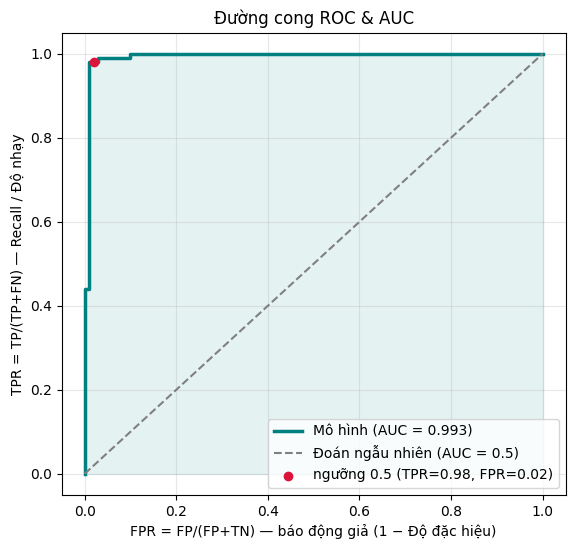

AUC = 0.9933   (1.0 = hoàn hảo · 0.5 = đoán bừa)


In [10]:
# ============ ROC & AUC — tính TƯỜNG MINH ============
def roc_curve_manual(y_true, scores):
    """Quét mọi ngưỡng → tính (FPR, TPR) tại từng ngưỡng."""
    thresholds = np.sort(np.unique(scores))[::-1]          # cao → thấp
    thresholds = np.concatenate(([np.inf], thresholds))    # bắt đầu: không gắn cờ ai
    P = np.sum(y_true == 1)   # tổng ca dương thật
    N = np.sum(y_true == 0)   # tổng ca âm thật
    tpr_list, fpr_list = [], []
    for t in thresholds:
        pred = (scores >= t).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        tpr_list.append(TP / P)   # TPR = Recall = Độ nhạy
        fpr_list.append(FP / N)   # FPR = 1 − Độ đặc hiệu (báo động giả)
    return np.array(fpr_list), np.array(tpr_list), thresholds

def auc_trapezoid(fpr, tpr):
    """AUC = diện tích dưới ROC, tính bằng tích phân hình thang."""
    trapz = getattr(np, "trapezoid", np.trapz)   # numpy 2.0 đổi tên trapz→trapezoid
    return trapz(tpr, fpr)

scores = model.predict_proba(X)                  # xác suất P(lớp 1)
fpr, tpr, thr = roc_curve_manual(y, scores)
auc = auc_trapezoid(fpr, tpr)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="teal", lw=2.5, label=f"Mô hình (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Đoán ngẫu nhiên (AUC = 0.5)")
plt.fill_between(fpr, tpr, alpha=0.1, color="teal")

# đánh dấu điểm ứng với ngưỡng mặc định 0.5
idx05 = int(np.argmin(np.abs(thr - 0.5)))
plt.scatter(fpr[idx05], tpr[idx05], color="crimson", zorder=5,
            label=f"ngưỡng 0.5 (TPR={tpr[idx05]:.2f}, FPR={fpr[idx05]:.2f})")

plt.xlabel("FPR = FP/(FP+TN) — báo động giả (1 − Độ đặc hiệu)")
plt.ylabel("TPR = TP/(TP+FN) — Recall / Độ nhạy")
plt.title("Đường cong ROC & AUC")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

print(f"AUC = {auc:.4f}   (1.0 = hoàn hảo · 0.5 = đoán bừa)")

✅ Dừng ở epoch 13754: max|đạo hàm| = 1.00e-05 < tol = 1e-05  | loss = 0.265797


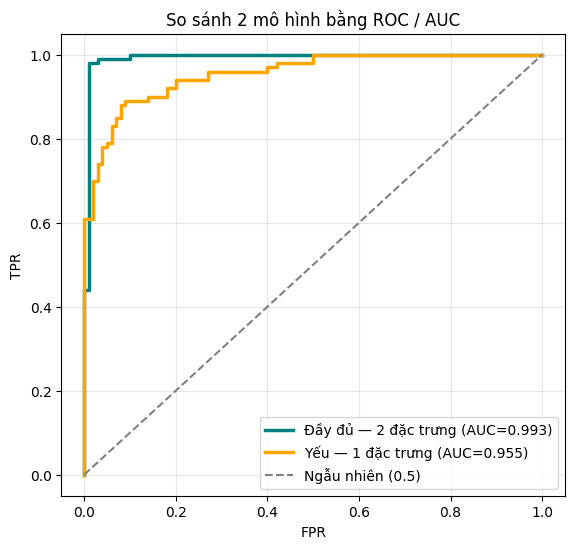

AUC đầy đủ = 0.993  >  AUC yếu = 0.955
→ Đường teal ôm góc trên-trái hơn & AUC lớn hơn ⇒ mô hình đầy đủ tốt hơn.


In [11]:
# So sánh 2 mô hình: ĐẦY ĐỦ (2 đặc trưng) vs YẾU (chỉ dùng 1 đặc trưng x1)
weak = LogisticRegressionGD(lr=0.1, max_epochs=50_000, tol=1e-5).fit(X[:, :1], y)
fpr_w, tpr_w, _ = roc_curve_manual(y, weak.predict_proba(X[:, :1]))
auc_w = auc_trapezoid(fpr_w, tpr_w)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr,   tpr,   color="teal",   lw=2.5, label=f"Đầy đủ — 2 đặc trưng (AUC={auc:.3f})")
plt.plot(fpr_w, tpr_w, color="orange", lw=2.5, label=f"Yếu — 1 đặc trưng (AUC={auc_w:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Ngẫu nhiên (0.5)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("So sánh 2 mô hình bằng ROC / AUC")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

print(f"AUC đầy đủ = {auc:.3f}  >  AUC yếu = {auc_w:.3f}")
print("→ Đường teal ôm góc trên-trái hơn & AUC lớn hơn ⇒ mô hình đầy đủ tốt hơn.")

## 12) Đường cong Precision–Recall (PR)

- **PR curve** = quét mọi ngưỡng, vẽ **Precision** theo **Recall**.
- **AP / PR-AUC** = diện tích dưới PR — tóm tắt chất lượng bằng 1 số.
- **Đường cơ sở** = **tỉ lệ lớp dương** trong dữ liệu (model đoán bừa sẽ nằm ở mức này).

### ❓ Vì sao ưu tiên PR hơn ROC khi dữ liệu MẤT CÂN BẰNG mạnh?

Mấu chốt nằm ở công thức **FPR = FP / (FP + TN)**.

Giả sử bài gian lận: **1.000.000 giao dịch, chỉ 100 là gian lận** (lớp dương hiếm). Model dự đoán và sinh ra **5.000 FP** (báo nhầm 5.000 giao dịch thường là gian lận):

| Góc nhìn | Tính | Kết quả | Cảm giác |
|---|---|---|---|
| **ROC** dùng FPR | FP/(FP+TN) = 5000 / (5000 + 995000) | **0.5%** | "Ô, sai số nhỏ xíu, model tuyệt vời!" 😍 |
| **PR** dùng Precision | TP/(TP+FP) = 100 / (100 + 5000) | **2%** | "Trời, 98% cảnh báo là SAI!" 😱 |

> 🔑 **TN khổng lồ** (995.000) làm **mẫu số của FPR phình to** → FPR luôn bé tí dù FP đã rất nhiều → **ROC trông đẹp một cách giả tạo (lạc quan quá mức)**.
> **Precision KHÔNG dùng TN** (chỉ TP và FP) → nó **phơi bày** sự thật rằng phần lớn cảnh báo là rác.
> ⇒ Lớp dương càng hiếm, **PR càng trung thực**, ROC càng dễ đánh lừa.

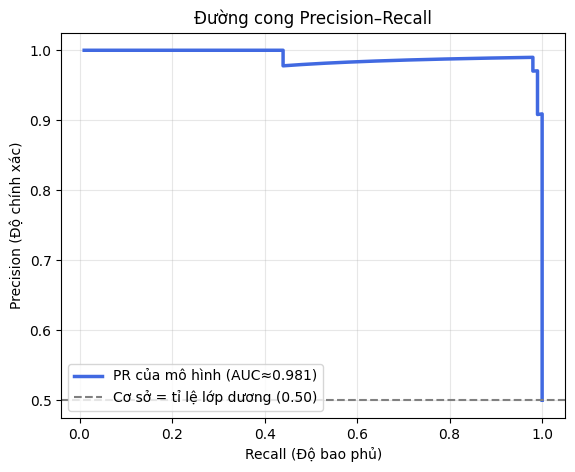

PR ôm góc trên-phải (Precision & Recall cùng cao) = tốt. Dữ liệu này cân bằng nên PR đẹp.


In [12]:
def pr_curve_manual(y_true, scores):
    """Quét mọi ngưỡng → (Recall, Precision)."""
    thresholds = np.sort(np.unique(scores))[::-1]   # cao → thấp
    P = np.sum(y_true == 1)
    rec_list, prec_list = [], []
    for t in thresholds:
        pred = (scores >= t).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        prec = TP / (TP + FP) if (TP + FP) > 0 else 1.0
        rec  = TP / P
        rec_list.append(rec); prec_list.append(prec)
    return np.array(rec_list), np.array(prec_list)

rec, prec = pr_curve_manual(y, scores)
ap = auc_trapezoid(rec, prec)          # diện tích dưới PR (Recall tăng dần)
baseline = y.mean()                    # tỉ lệ lớp dương

plt.figure(figsize=(6.5, 5))
plt.plot(rec, prec, color="royalblue", lw=2.5, label=f"PR của mô hình (AUC≈{ap:.3f})")
plt.axhline(baseline, ls="--", color="gray", label=f"Cơ sở = tỉ lệ lớp dương ({baseline:.2f})")
plt.xlabel("Recall (Độ bao phủ)"); plt.ylabel("Precision (Độ chính xác)")
plt.title("Đường cong Precision–Recall")
plt.legend(loc="lower left"); plt.grid(alpha=0.3)
plt.show()
print("PR ôm góc trên-phải (Precision & Recall cùng cao) = tốt. Dữ liệu này cân bằng nên PR đẹp.")

---
## 13) Mất cân bằng lớp (Class Imbalance)

**Vấn đề:** một lớp áp đảo (vd 98% âm, 2% dương — gian lận, bệnh hiếm, lỗi thiết bị). Model "lười" chỉ cần **luôn đoán lớp đa số** đã đạt Accuracy rất cao, nhưng **bỏ sót sạch lớp hiếm** — mà lớp hiếm mới là cái ta cần bắt!

### 📋 Lúc này XEM những thông số nào? (và vì sao)

| Thông số | Vì sao quan trọng khi lệch |
|---|---|
| ❌ **KHÔNG xem Accuracy** | Bị lớp đa số "nuốt" → 98% nhưng vô dụng |
| ✅ **Recall** (lớp dương) | "Bắt được bao nhiêu ca hiếm?" — thường là **mục tiêu chính** |
| ✅ **Precision** (lớp dương) | "Cảnh báo có đáng tin không, hay toàn báo nhầm?" |
| ✅ **F1** | Cân bằng Precision–Recall trong 1 số |
| ✅ **PR-AUC** | Trung thực hơn ROC-AUC khi lệch nặng (xem Mục 12) |
| ✅ **Confusion Matrix** | Nhìn thẳng FN (bỏ sót) và FP (báo nhầm) bằng số tuyệt đối |
| ✅ **Balanced Accuracy** | Trung bình Recall của **từng lớp** (công bằng giữa 2 lớp) |

> 👉 Tư duy: **bỏ Accuracy, soi Recall + Precision + F1 của RIÊNG lớp hiếm**, kèm confusion matrix để thấy con số thật.

Chạy thử để **thấy tận mắt cái bẫy** 👇

In [13]:
def make_imbalanced(n=3000, pos_ratio=0.02, seed=1):
    """Lớp dương HIẾM (pos_ratio) và chồng lấn với lớp âm → dễ bị bỏ sót."""
    rng = np.random.default_rng(seed)
    n_pos = int(n * pos_ratio); n_neg = n - n_pos
    Xn = rng.normal([3.0, 3.0], 1.5, size=(n_neg, 2))   # lớp âm (đa số)
    Xp = rng.normal([5.0, 5.0], 1.5, size=(n_pos, 2))   # lớp dương (hiếm, chồng lấn)
    X = np.vstack([Xn, Xp])
    y = np.array([0] * n_neg + [1] * n_pos, dtype=float)
    return X, y

def report(y_true, y_pred, name=""):
    TP, FP, FN, TN = confusion_matrix_manual(y_true, y_pred)
    acc, prec, rec, f1 = metrics_from_cm(TP, FP, FN, TN)
    print(f"[{name:<14}] Acc={acc:.3f} | Precision={prec:.3f} | "
          f"Recall={rec:.3f} | F1={f1:.3f} | TP={TP} FN={FN} FP={FP} TN={TN}")
    return acc, prec, rec, f1

Xi, yi = make_imbalanced()
print(f"Tỉ lệ lớp:  âm = {np.mean(yi==0):.1%},  dương = {np.mean(yi==1):.1%}\n")

mi = LogisticRegressionGD(lr=0.1, max_epochs=50_000).fit(Xi, yi)
print("Đoán 'tất cả là ÂM' (model lười):")
report(yi, np.zeros_like(yi), "all-negative")
print("\nMô hình logistic, ngưỡng 0.5:")
report(yi, mi.predict(Xi), "logistic 0.5")
print("\n⚠️ Accuracy cao chót vót nhưng Recall thấp → bỏ sót nhiều ca hiếm. Accuracy ĐÁNH LỪA.")

Tỉ lệ lớp:  âm = 98.0%,  dương = 2.0%



⚠️ Chạm trần 50000 epoch (max|đạo hàm| = 1.60e-04).
Đoán 'tất cả là ÂM' (model lười):
[all-negative  ] Acc=0.980 | Precision=0.000 | Recall=0.000 | F1=0.000 | TP=0 FN=60 FP=0 TN=2940

Mô hình logistic, ngưỡng 0.5:
[logistic 0.5  ] Acc=0.980 | Precision=0.533 | Recall=0.133 | F1=0.213 | TP=8 FN=52 FP=7 TN=2933

⚠️ Accuracy cao chót vót nhưng Recall thấp → bỏ sót nhiều ca hiếm. Accuracy ĐÁNH LỪA.


### 🛠️ 4 cách xử lý mất cân bằng

**① Lấy mẫu lại (Resampling)** — *sửa DỮ LIỆU cho cân bằng*
- **Oversampling**: nhân thêm mẫu lớp hiếm. **SMOTE** = sinh mẫu "tổng hợp" bằng cách nội suy giữa các mẫu hiếm gần nhau (không chỉ copy y hệt).
- **Undersampling**: bớt mẫu lớp đa số.
- *Ví dụ:* 100 gian lận / 9900 thường → nhân lớp gian lận lên ~×50 cho ngang nhau, rồi mới train.
- ⚠️ **Chỉ resample trên tập TRAIN**, không đụng test (kẻo rò rỉ → điểm ảo).

**② Trọng số lớp (Class Weight)** — *giữ nguyên dữ liệu, sửa HÀM MẤT MÁT*
- Phạt lỗi ở lớp hiếm **nặng hơn** (vd sai 1 ca gian lận = phạt bằng sai 50 ca thường).
- Trong sklearn chỉ cần `class_weight='balanced'`. Bản chất: nhân mỗi mẫu một **trọng số** vào gradient.
- *Ví dụ:* model "lười đoán âm" giờ bị phạt rất đau mỗi lần bỏ sót dương → buộc phải chú ý lớp hiếm.

**③ Dịch ngưỡng (Threshold shifting)** — *giữ model, chỉnh "núm vặn"*
- **Hạ ngưỡng** từ 0.5 xuống (vd 0.2) → gắn cờ Dương dễ hơn → **Recall ↑** (đánh đổi Precision ↓).
- *Ví dụ:* tầm soát bệnh → hạ ngưỡng để **không bỏ sót**, chấp nhận báo nhầm nhiều hơn (sẽ xét nghiệm lại sau).

**④ Dùng đúng độ đo** — *đừng để Accuracy lừa*
- Nhìn **Recall / Precision / F1 / PR-AUC**, KHÔNG nhìn Accuracy (đã giải thích Mục 10 & 12).

Xem hiệu quả từng cách 👇

In [14]:
sig = LogisticRegressionGD.sigmoid     # dùng lại sigmoid ổn định số học

print("So sánh các cách xử lý mất cân bằng (đo trên chính dữ liệu lệch):\n")
report(yi, mi.predict(Xi), "GỐC 0.5")        # baseline để đối chiếu

# ① LẤY MẪU LẠI — oversampling lớp hiếm (nhân bản + nhiễu nhỏ ~ SMOTE thô)
def oversample(X, y, seed=0):
    rng = np.random.default_rng(seed)
    Xp, Xn = X[y == 1], X[y == 0]
    k = len(Xn) // len(Xp)                                  # nhân cho ngang lớp âm
    Xp_os = np.repeat(Xp, k, axis=0) + rng.normal(0, 0.15, size=(len(Xp) * k, 2))
    Xb = np.vstack([Xn, Xp_os])
    yb = np.array([0] * len(Xn) + [1] * len(Xp_os), dtype=float)
    return Xb, yb

Xb, yb = oversample(Xi, yi)
m_os = LogisticRegressionGD(lr=0.1, max_epochs=50_000).fit(Xb, yb)
report(yi, m_os.predict(Xi), "① oversample")

# ② TRỌNG SỐ LỚP — phạt lỗi lớp hiếm nặng hơn (sample_weight kiểu 'balanced')
n = len(yi)
w_pos = n / (2 * np.sum(yi == 1))      # lớp hiếm → trọng số lớn
w_neg = n / (2 * np.sum(yi == 0))
sw = np.where(yi == 1, w_pos, w_neg)

w, b0, alpha = np.zeros(Xi.shape[1]), 0.0, 0.1
for _ in range(50_000):
    p = sig(Xi @ w + b0)
    err = (p - yi) * sw                # nhân trọng số vào sai số
    w  -= alpha * (Xi.T @ err) / n
    b0 -= alpha * np.mean(err)
pred_w = (sig(Xi @ w + b0) >= 0.5).astype(int)
report(yi, pred_w, "② class_weight")

# ③ DỊCH NGƯỠNG — hạ xuống 0.2 để tăng Recall lớp hiếm
report(yi, (mi.predict_proba(Xi) >= 0.2).astype(int), "③ ngưỡng 0.2")

print("\n→ ①②③ đều KÉO RECALL LÊN (bắt được nhiều ca hiếm hơn), đánh đổi Precision giảm chút.")
print("→ ④ Đúng độ đo: nhìn Recall/F1 ở trên thay vì Accuracy để thấy cải thiện thật.")

So sánh các cách xử lý mất cân bằng (đo trên chính dữ liệu lệch):

[GỐC 0.5       ] Acc=0.980 | Precision=0.533 | Recall=0.133 | F1=0.213 | TP=8 FN=52 FP=7 TN=2933


✅ Dừng ở epoch 20564: max|đạo hàm| = 1.00e-05 < tol = 1e-05  | loss = 0.341002
[① oversample  ] Acc=0.846 | Precision=0.103 | Recall=0.867 | F1=0.184 | TP=52 FN=8 FP=453 TN=2487


[② class_weight] Acc=0.847 | Precision=0.103 | Recall=0.867 | F1=0.184 | TP=52 FN=8 FP=452 TN=2488
[③ ngưỡng 0.2  ] Acc=0.975 | Precision=0.383 | Recall=0.383 | F1=0.383 | TP=23 FN=37 FP=37 TN=2903

→ ①②③ đều KÉO RECALL LÊN (bắt được nhiều ca hiếm hơn), đánh đổi Precision giảm chút.
→ ④ Đúng độ đo: nhìn Recall/F1 ở trên thay vì Accuracy để thấy cải thiện thật.
